In [3]:
import torch

from models.SCatt import SCAttGenerator

# Quantidade de nós por comunidade
y = [200, 200, 200]
k = len(y)

# Número de arestas internas/homogêneas por comunidade
e = [350, 350, 350]

# Proporção das subcomunidades dentro de cada comunidade
M = [
    torch.tensor([1.0]),          # comunidade 0: uma subcomunidade
    torch.tensor([0.5, 0.5]),     # comunidade 1: duas subcomunidades
    torch.tensor([0.7, 0.3]),     # comunidade 2: duas subcomunidades
]

# Como as subcomunidades se conectam dentro de cada comunidade
C = [
    torch.tensor([[1.0]]),
    torch.tensor([
        [0.8, 0.2],
        [0.2, 0.8],
    ]),
    torch.tensor([
        [0.9, 0.1],
        [0.1, 0.9],
    ]),
]

# Como comunidades diferentes se conectam
# A diagonal precisa ser zero
N = torch.tensor([
    [0.0, 0.5, 0.5],
    [0.5, 0.0, 0.5],
    [0.5, 0.5, 0.0],
])

graph = SCAttGenerator(seed=42).generate(
    num_nodes=sum(y),
    y=y,
    k=k,
    e=e,
    C=C,
    d=["power_law", "normal", "uniform"],
    rho=0.01,
    N=N,
    M=M,
    dimensions=512,
    sigma=0.2,
    alpha=0.6,
)

print(graph)


AttributedGraph(n_nodes=488, n_edges=1189, x_shape=(488, 512), y_shape=(488,))


In [ ]:
import torch


def measure_homophily_heterophily(data, ignore_self_loops=True, undirected=True):
    """
    Mede homofilia e heterofilia de um grafo no formato PyTorch Geometric.

    Parâmetros
    ----------
    data : torch_geometric.data.Data
        Objeto Data do PyG contendo pelo menos:
        - data.edge_index: tensor [2, num_edges]
        - data.y: tensor [num_nodes]

    ignore_self_loops : bool
        Se True, ignora arestas do tipo (i, i).

    undirected : bool
        Se True, evita contar duas vezes arestas duplicadas em grafos não direcionados,
        por exemplo (i, j) e (j, i).

    Retorna
    -------
    dict
        Dicionário com homofilia, heterofilia e contagens de arestas.
    """

    edge_index = data.edge_index
    y = data.y

    src = edge_index[0]
    dst = edge_index[1]

    # Remove self-loops, se desejado
    if ignore_self_loops:
        mask = src != dst
        src = src[mask]
        dst = dst[mask]

    # Evita contar duas vezes arestas simétricas em grafos não direcionados
    if undirected:
        mask = src < dst
        src = src[mask]
        dst = dst[mask]

    # Garante que estamos comparando vetores 1D
    y = y.view(-1)

    # Compara os rótulos dos nós conectados
    same_class = y[src] == y[dst]

    num_edges = same_class.numel()
    num_same = same_class.sum().item()
    num_diff = num_edges - num_same

    if num_edges == 0:
        return {
            "homophily": None,
            "heterophily": None,
            "num_edges": 0,
            "num_same_class_edges": 0,
            "num_different_class_edges": 0,
        }

    homophily = num_same / num_edges
    heterophily = num_diff / num_edges

    return {
        "homophily": homophily,
        "heterophily": heterophily,
        "num_edges": num_edges,
        "num_same_class_edges": num_same,
        "num_different_class_edges": num_diff,
    }

In [4]:
dt = graph.to_data_pytorch()

In [5]:
torch.save(dt, "scatt_graph.pt")

/home/gui-messias/miniconda3/envs/graphgen_venv/lib/python3.10/site-packages/netgraph/_edge_layout.py:978: RuntimeWarning: invalid value encountered in divide
  displacement = compatibility * delta / distance_squared[..., None]
/home/gui-messias/miniconda3/envs/graphgen_venv/lib/python3.10/site-packages/netgraph/_utils.py:360: RuntimeWarning: invalid value encountered in divide
  v = v / np.linalg.norm(v, axis=-1)[:, None] # unit vector


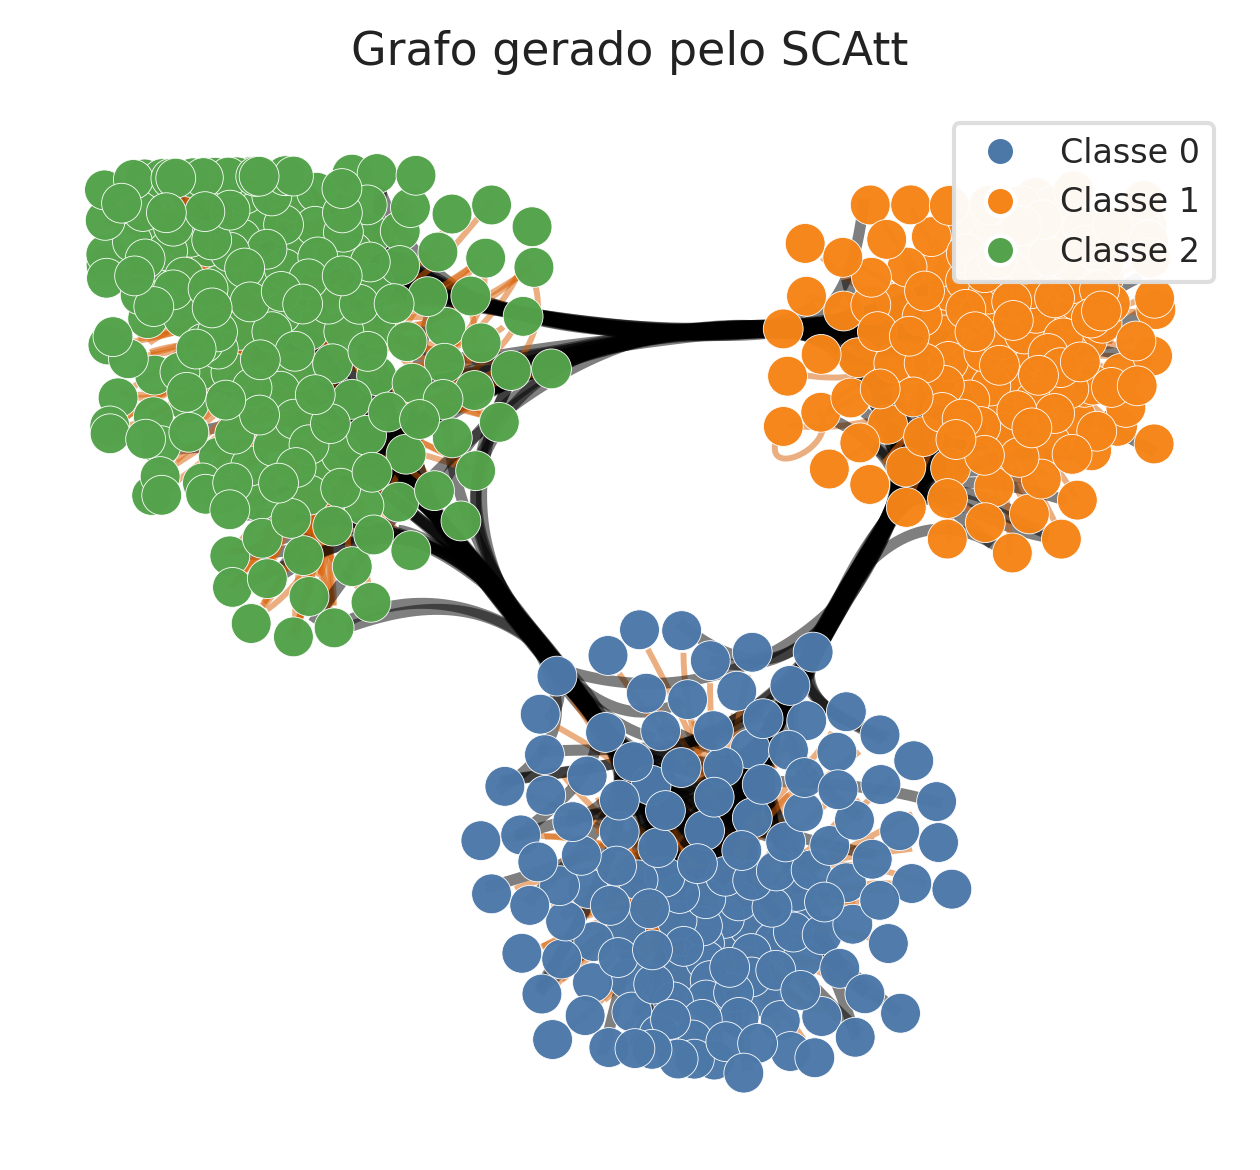

In [2]:
from plot.plot import graphPlotter

plotter = graphPlotter()

fig, ax = plotter.plot_scatt_graph(
    graph,
    backend="netgraph",
    layout="community",
    netgraph_edge_layout="bundled",
    vertex_size_range=(2, 5),
    intraclass_edge_color="#D95F02",
    interclass_edge_color="Black",
    intraclass_edge_width=0.7,
    interclass_edge_width=1.3,
    edge_alpha=0.5,
    interclass_edge_alpha=0.25,
    node_edge_width=0.1,
    figsize=(6, 4),
    save_path="scatt_publication.png",
)


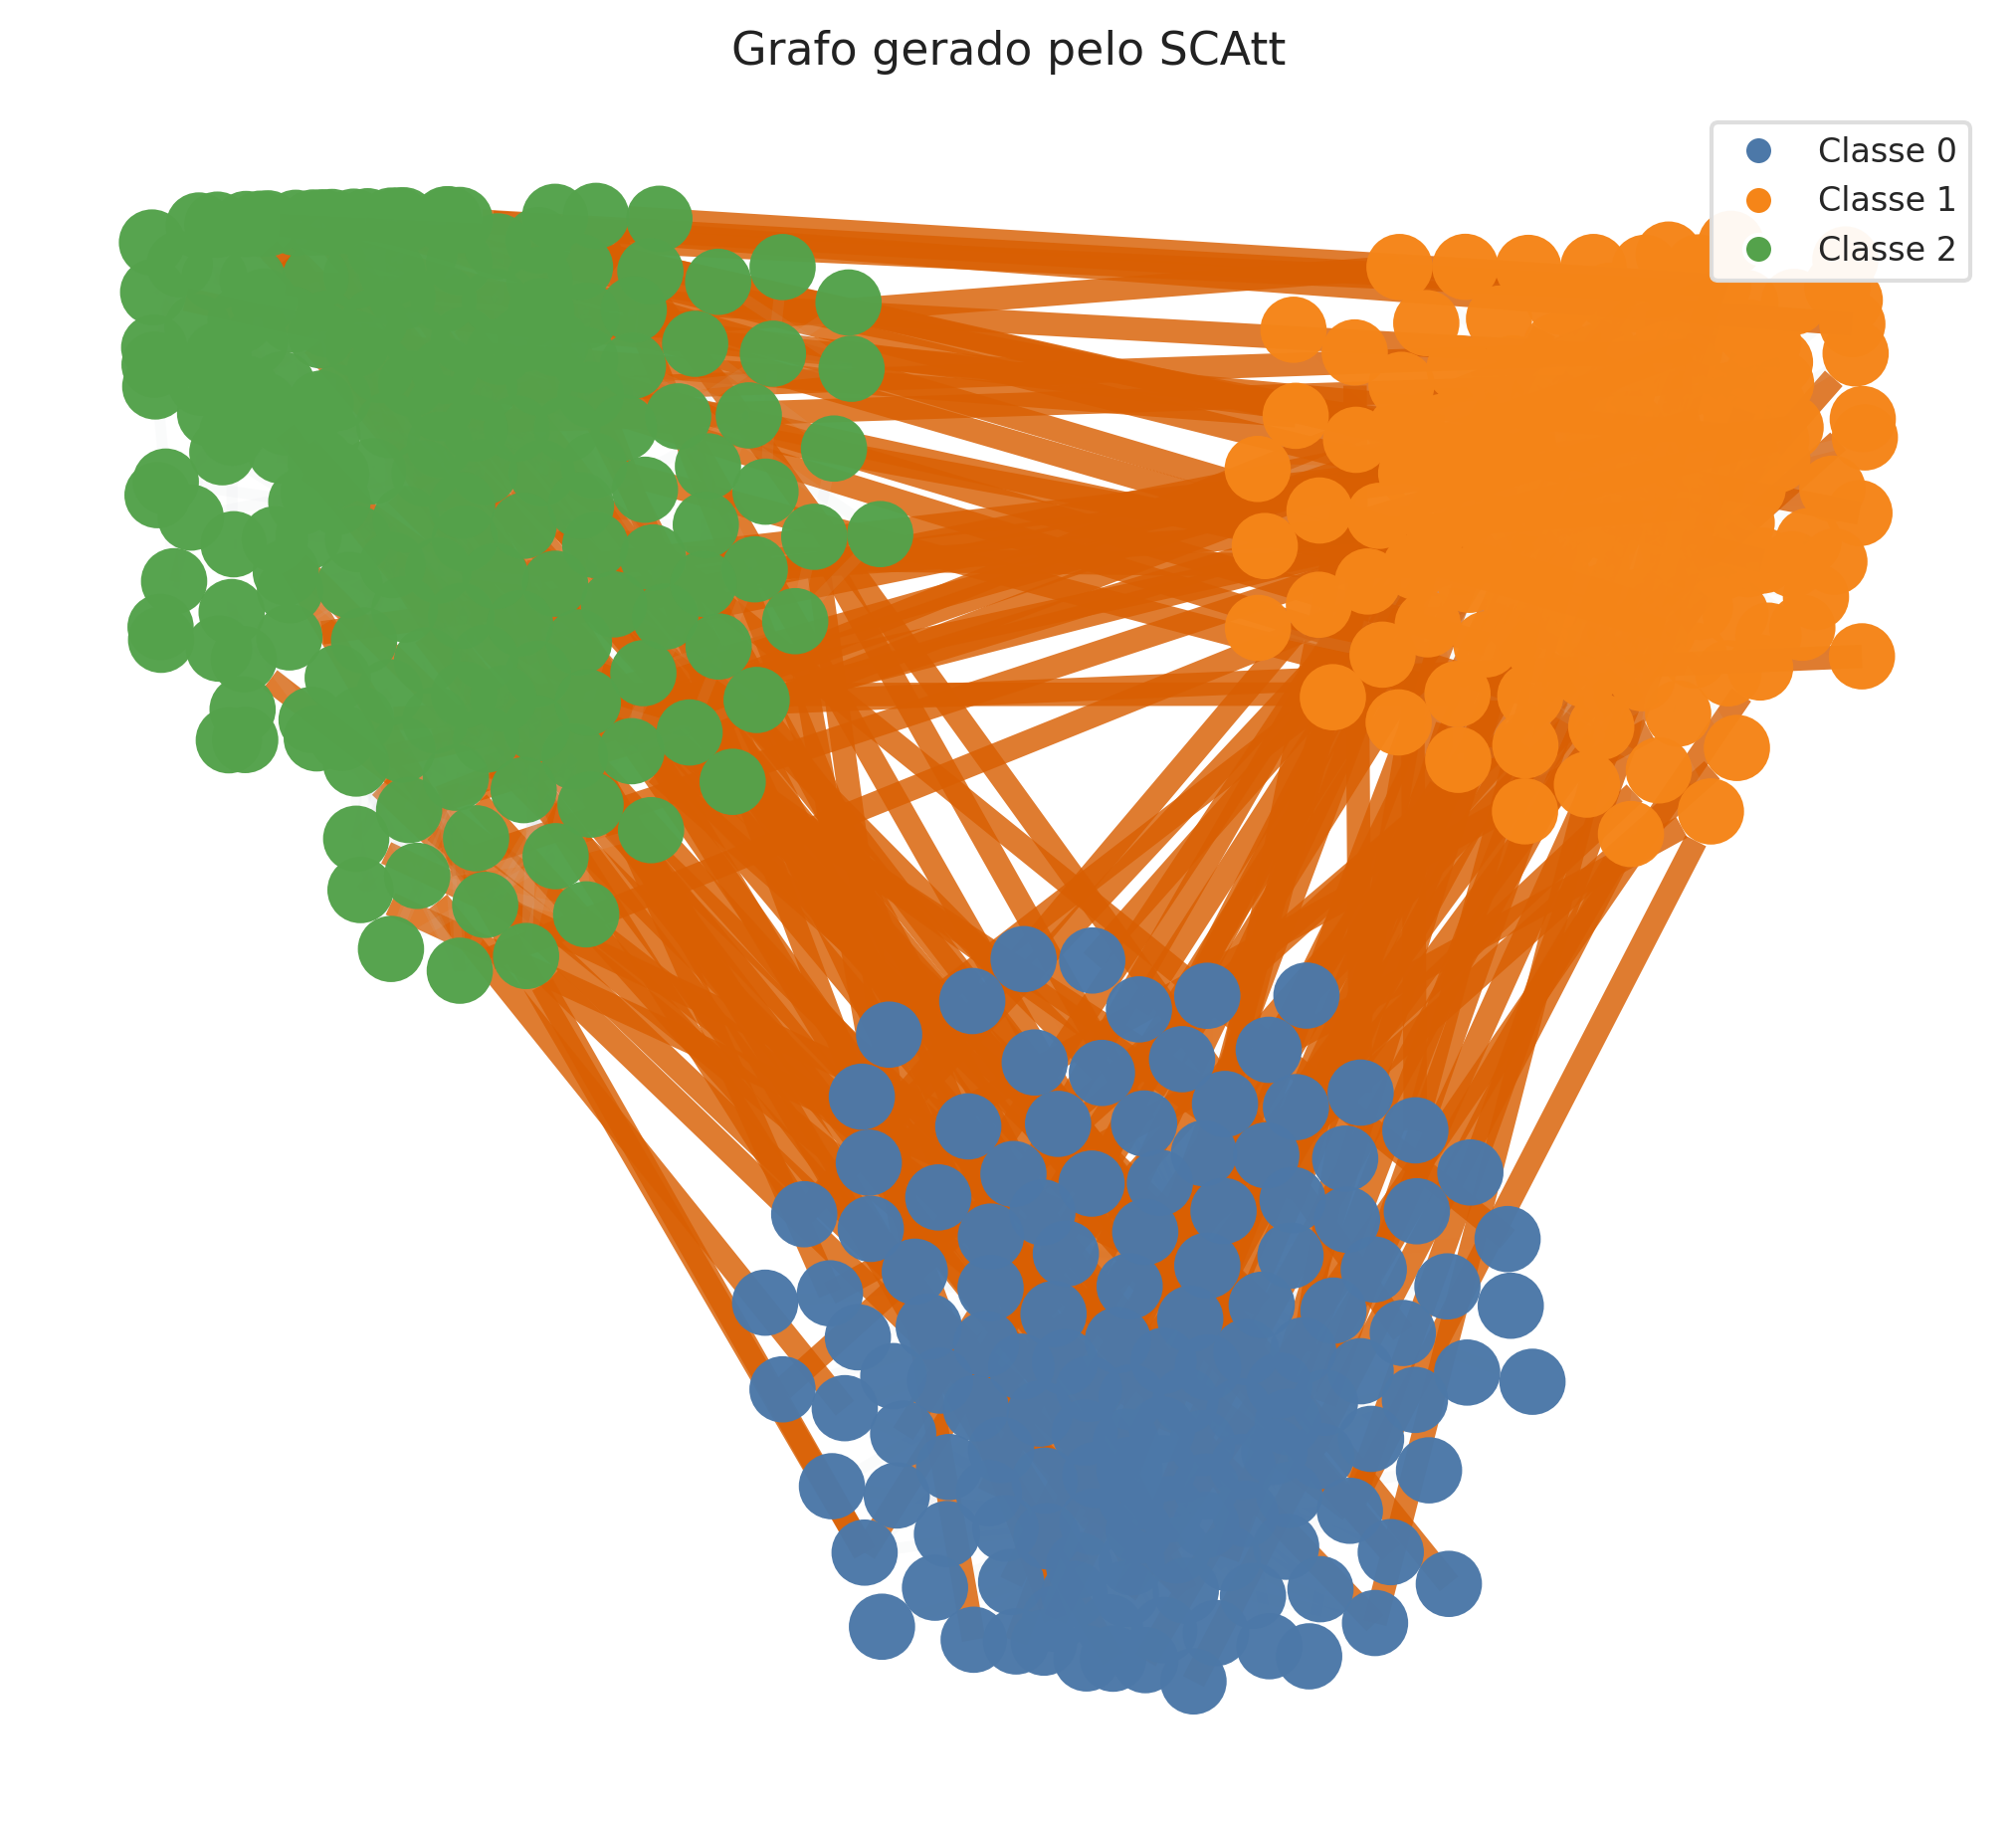

In [18]:
fig, ax = plotter.plot_scatt_graph(
    graph,
    backend="netgraph",
    layout="community",
    netgraph_edge_layout="straight",
    vertex_size_range=(40, 80),
    edge_alpha=0.08,
    node_edge_width=0,
)
